# Week 11: Data Visualisation with `plotnine` - Class Exercises

We first load the packages necessary for this week's exercises.

Let us use `plotnine` for our visualisations.

In [2]:
import pandas as pd
import numpy as np


In [3]:
!pip install plotnine


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
from plotnine import *

# 1. Human Development Index

Recall the HDI data from Week 10's class exercise.

The file `UN_HDI_2021.xlsx` contains the HDI scores for 191 countries in 1990 and 2021, and a spreadsheet that groups the countries into broad geographical regions in the world.

Recreate, using `plotnine`, the following panels of slope charts that visualise how the HDI has changed for countries between 1990 and 2001.

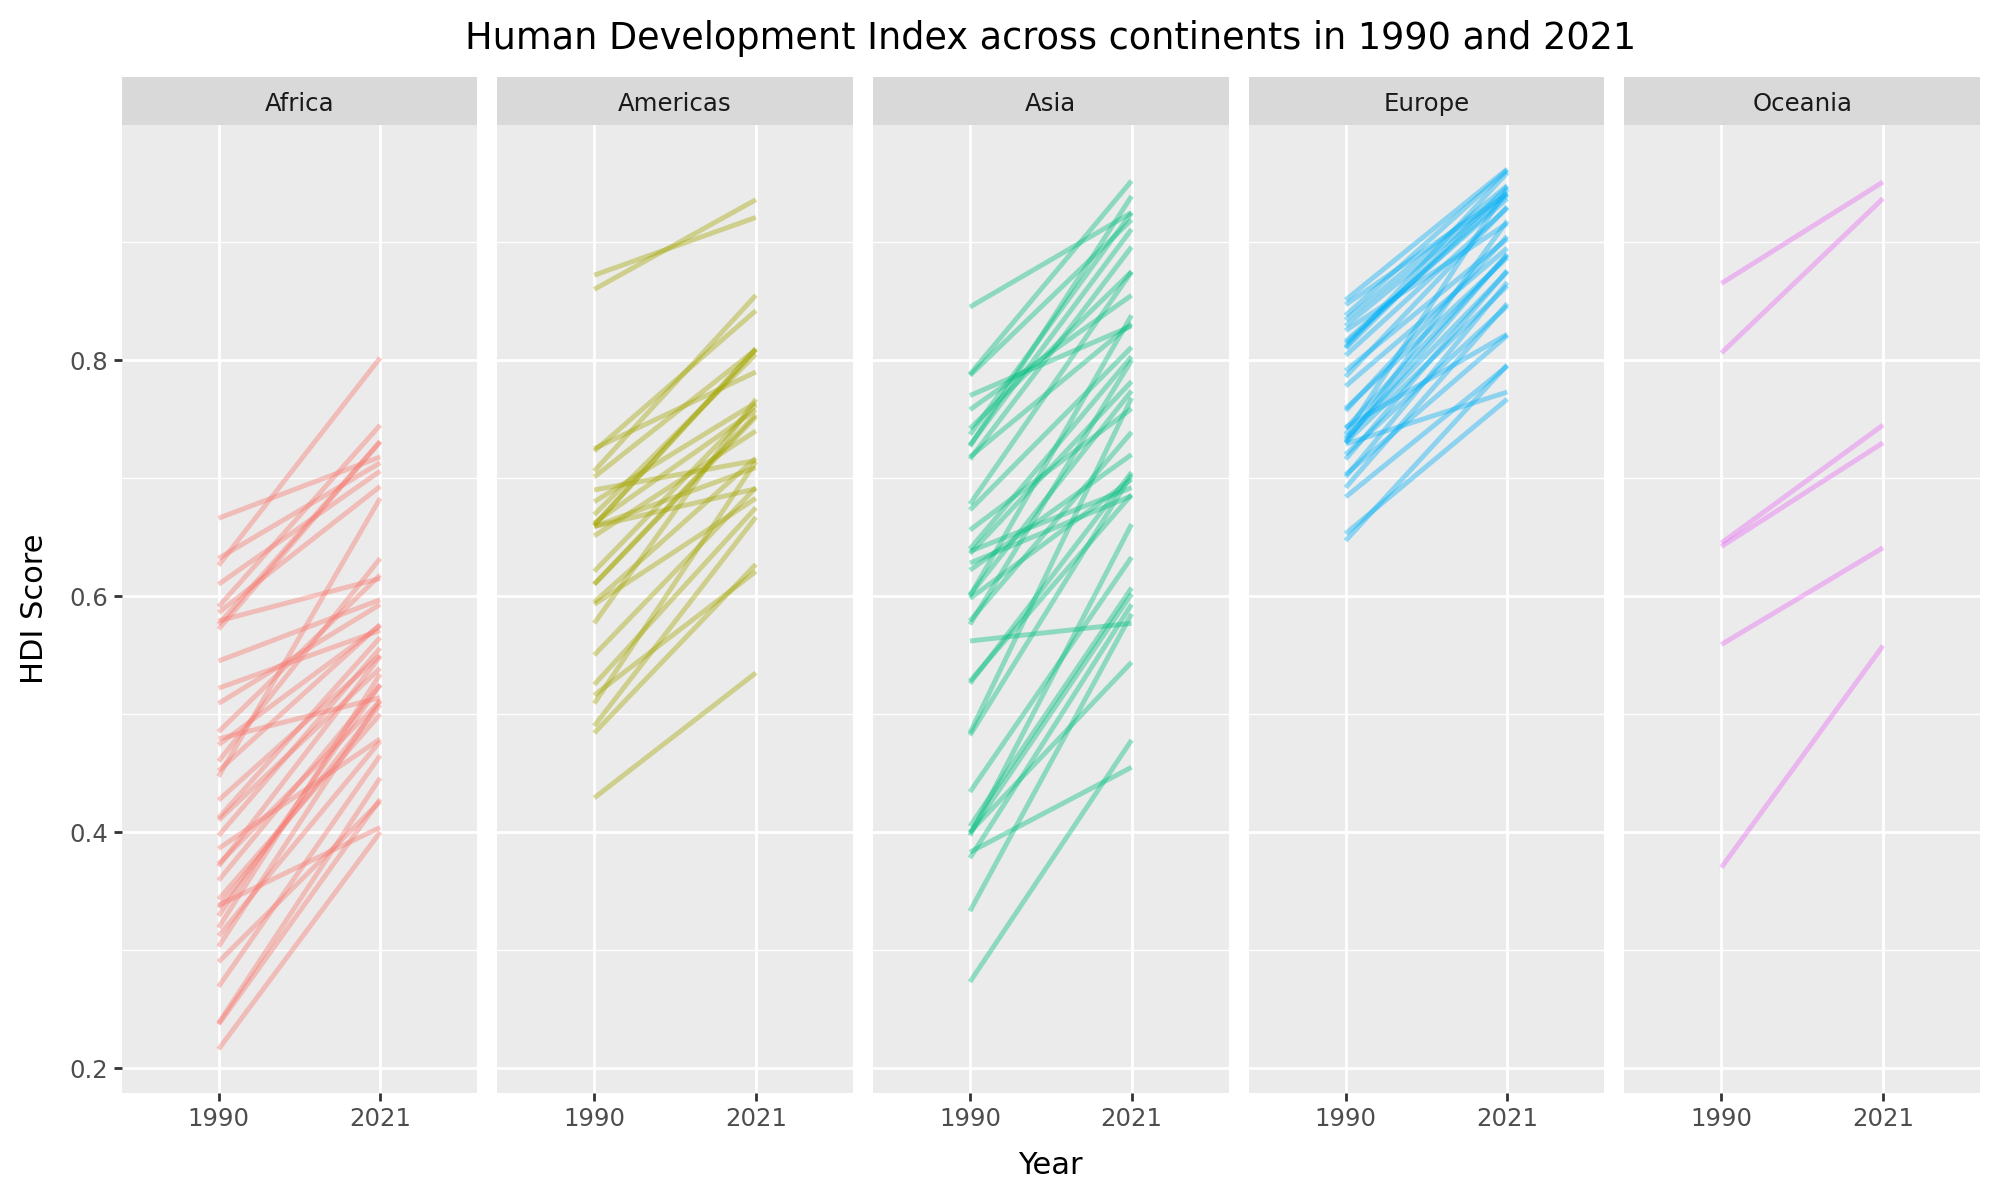

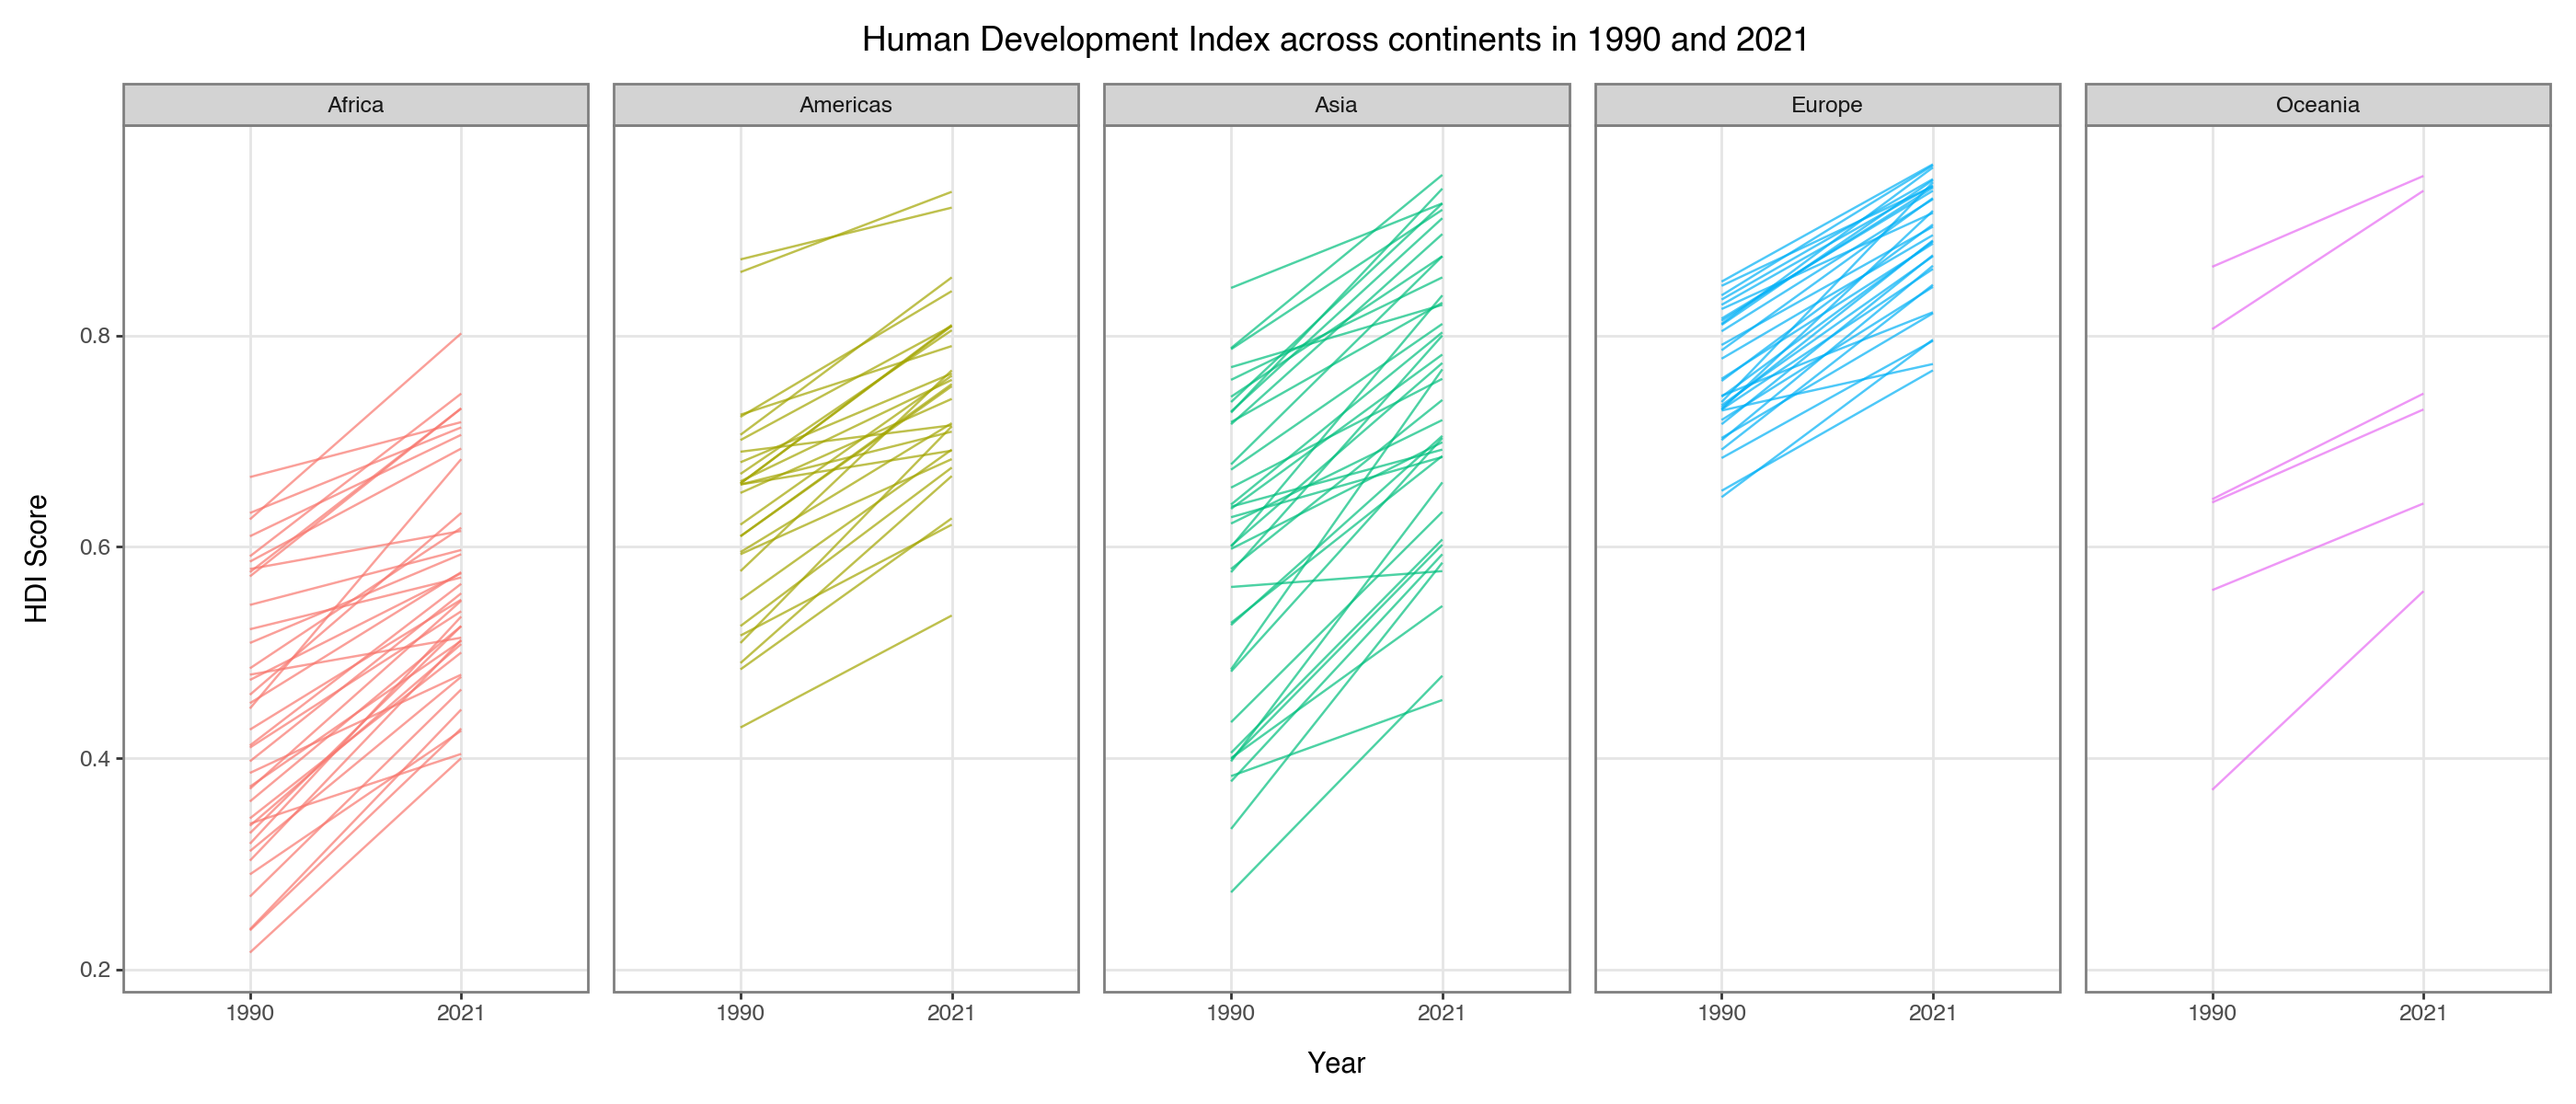

In [16]:
import pandas as pd
from plotnine import *

# --- Load and prepare data ---
hdi = pd.read_excel("data/UN_HDI_2021.xlsx", sheet_name="Sheet1", header=3)
hdi.columns = ["Country", "1990", "2021"]
hdi = hdi[hdi["Country"] != "Country"].dropna(subset=["Country"])
hdi = hdi[~hdi["1990"].isna() & ~hdi["2021"].isna()]

regions = pd.read_excel("data/UN_HDI_2021.xlsx", sheet_name="Sheet2")

df = hdi.merge(regions[["country", "Region.Name"]], left_on="Country", right_on="country", how="inner")

# Rename to avoid dot in column name (plotnine treats dot as formula operator)
df = df.rename(columns={"Region.Name": "Continent"})

df_long = df.melt(
    id_vars=["Country", "Continent"],
    value_vars=["1990", "2021"],
    var_name="Year",
    value_name="HDI_Score"
)
df_long["HDI_Score"] = pd.to_numeric(df_long["HDI_Score"], errors="coerce")

# --- Plot ---
(
    ggplot(df_long, aes(x="Year", y="HDI_Score", group="Country", color="Continent"))
    + geom_line(alpha=0.7)
    + facet_wrap("~Continent", nrow=1)
    + labs(
        title="Human Development Index across continents in 1990 and 2021",
        x="Year",
        y="HDI Score"
    )
    + theme_bw()
    + theme(
        legend_position="none",
        figure_size=(14, 6),
        strip_background=element_rect(fill="lightgrey"),
        panel_grid_minor=element_blank()
    )
)

# 2. Summer Olympics

The file `olympics.csv` contains information on athletes, countries and medals won at the Olympic Games up between 1896 to 2016.

(a) Tabulate the number of athletes who participated in each of the Summer Olympics since 1896. Name your dataframe `games`.

The first few rows of `games` should look like this:

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>year</th>
      <th>count</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>1896</td>
      <td>380</td>
    </tr>
    <tr>
      <th>1</th>
      <td>1900</td>
      <td>1936</td>
    </tr>
    <tr>
      <th>2</th>
      <td>1904</td>
      <td>1301</td>
    </tr>
    <tr>
      <th>3</th>
      <td>1906</td>
      <td>1733</td>
    </tr>
    <tr>
      <th>4</th>
      <td>1908</td>
      <td>3101</td>
    </tr>
  </tbody>
</table>
</div>

In [18]:
# Type your code here:
import pandas as pd

olympics = pd.read_csv("data/olympics.csv")

print(olympics.head())

   id                      name sex   age  height  weight            team  \
0   1                 A Dijiang   M  24.0   180.0    80.0           China   
1   2                  A Lamusi   M  23.0   170.0    60.0           China   
2   3       Gunnar Nielsen Aaby   M  24.0     NaN     NaN         Denmark   
3   4      Edgar Lindenau Aabye   M  34.0     NaN     NaN  Denmark/Sweden   
4   5  Christine Jacoba Aaftink   F  21.0   185.0    82.0     Netherlands   

   noc        games  year  season       city          sport  \
0  CHN  1992 Summer  1992  Summer  Barcelona     Basketball   
1  CHN  2012 Summer  2012  Summer     London           Judo   
2  DEN  1920 Summer  1920  Summer  Antwerpen       Football   
3  DEN  1900 Summer  1900  Summer      Paris     Tug-Of-War   
4  NED  1988 Winter  1988  Winter    Calgary  Speed Skating   

                              event medal  
0       Basketball Men's Basketball   NaN  
1      Judo Men's Extra-Lightweight   NaN  
2           Football Men's

In [20]:
import pandas as pd

olympics = pd.read_csv("data/olympics.csv")

# Keep Summer Olympics only, drop duplicate athletes per year (same athlete, same games)
games = (
    olympics[olympics["season"] == "Summer"]
    .drop_duplicates(subset=["id", "year"])
    .groupby("year", as_index=False)
    .agg(count=("id", "count"))
)

print(games.head())

   year  count
0  1896    176
1  1900   1224
2  1904    650
3  1906    841
4  1908   2024


(b) Reproduce the following plot, which depicts the number of athletes taking part in the Summer Olympics Games.

**Hint**\
(1) The two World Wars happened between 1914 to 1918 and 1939 to 1945 respectively.\
To draw the rectangles, checkout an example shown on https://plotnine.org/guide/annotations.html and the `geom_rect` documentation https://plotnine.org/reference/geom_rect.html 

(2) The following events ["Great Depression", "Suez Crisis", "African Boycott", "Cold War", "Cold War"] happened during the [1932, 1956, 1976, 1980, 1984] edition of the Olympic Games respectively.\
To annotate these events, create a data frame with the columns `year`, `count`, `events` **just for the years concerned** and make use of `geom_text`: https://plotnine.org/reference/geom_text.html 

(3) For the two `geom`s above, take note of the `inherit_aes` argument.

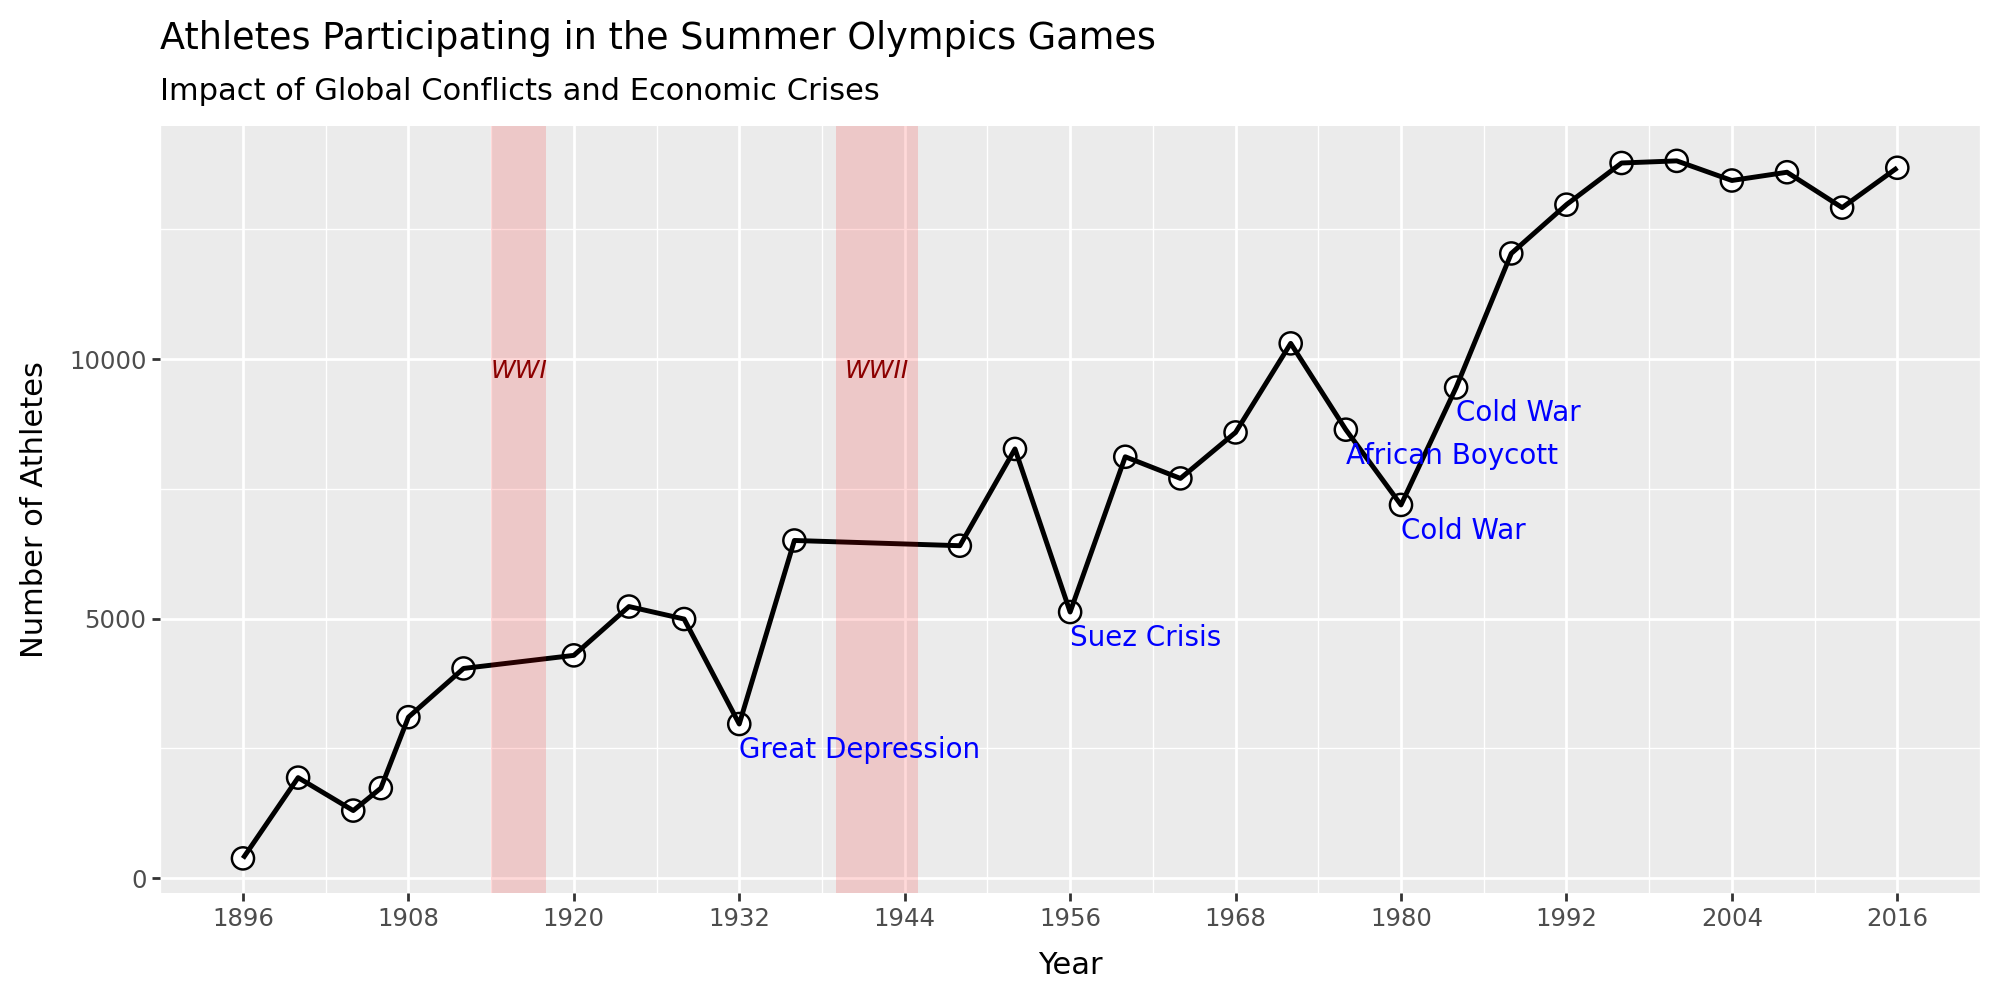

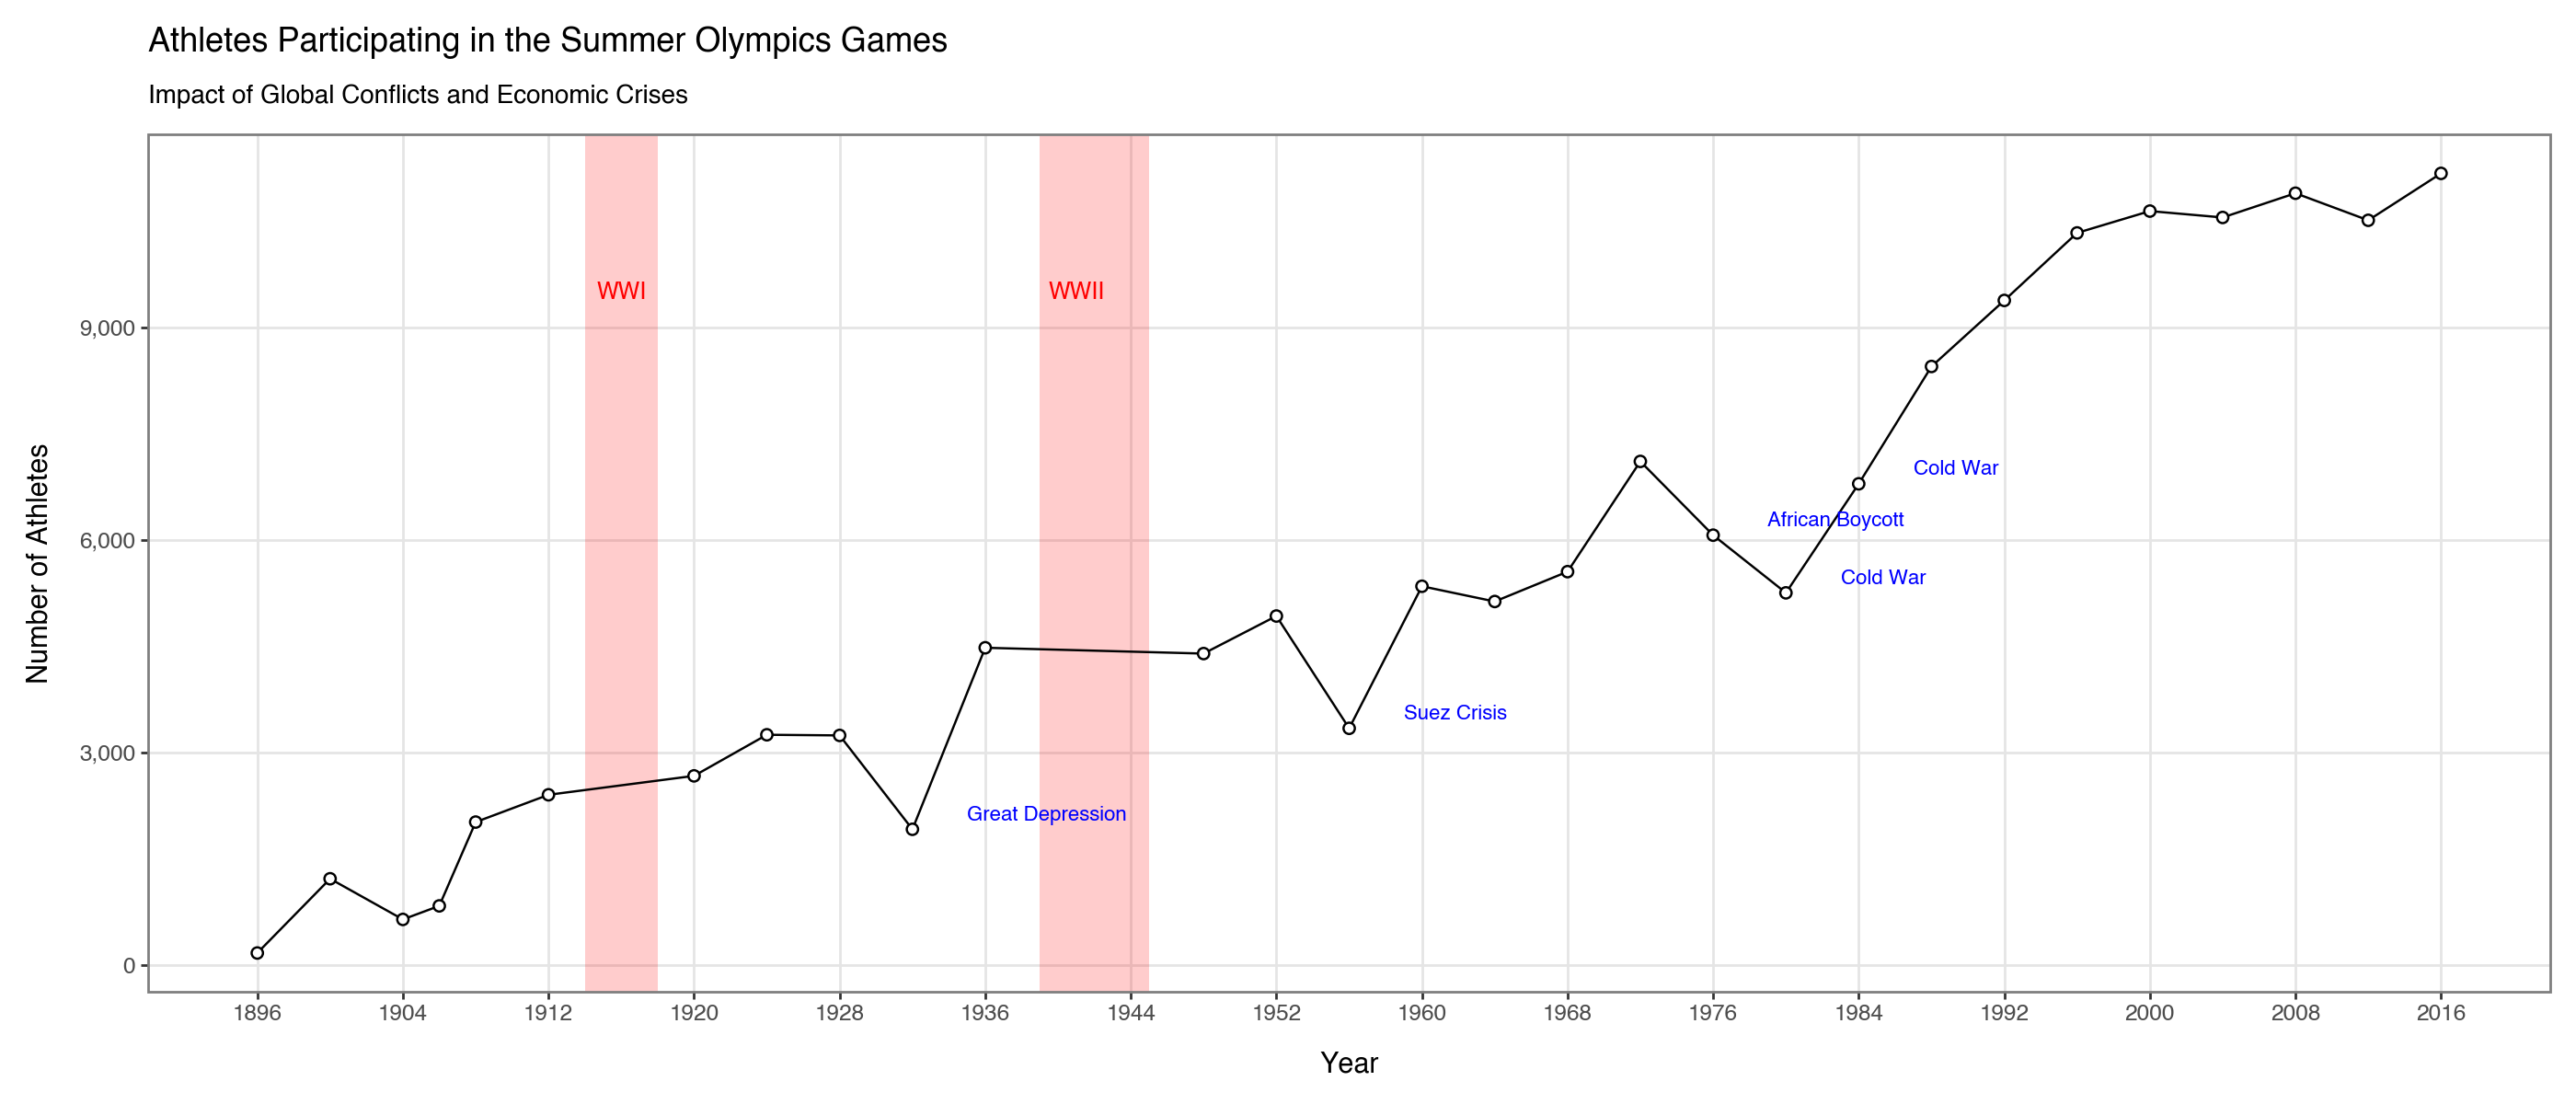

In [21]:
# Type your code here:
import pandas as pd
from plotnine import *

olympics = pd.read_csv("data/olympics.csv")

# --- Check your column names and adjust these if needed ---
# print(olympics.columns.tolist())

# (a) Build games DataFrame - count unique athletes per Summer Olympics year
games = (
    olympics[olympics["season"] == "Summer"]   # filter Summer games
    .drop_duplicates(subset=["id", "year"])     # one row per athlete per year
    .groupby("year", as_index=False)
    .agg(count=("id", "count"))
)
games.columns = ["year", "count"]

# --- Data for WWI and WWII rectangles ---
wars = pd.DataFrame({
    "xmin": [1914, 1939],
    "xmax": [1918, 1945],
    "ymin": [-float("inf"), -float("inf")],
    "ymax": [float("inf"), float("inf")]
})

# --- Data for event annotations ---
events = pd.DataFrame({
    "year":   [1932, 1956, 1976, 1980, 1984],
    "count":  [games.loc[games["year"] == y, "count"].values[0] for y in [1932, 1956, 1976, 1980, 1984]],
    "events": ["Great Depression", "Suez Crisis", "African Boycott", "Cold War", "Cold War"]
})

# --- Plot ---
(
    ggplot(games, aes(x="year", y="count"))
    + geom_rect(
        data=wars,
        mapping=aes(xmin="xmin", xmax="xmax", ymin="ymin", ymax="ymax"),
        fill="red", alpha=0.2,
        inherit_aes=False
    )
    + geom_line(color="black")
    + geom_point(shape="o", fill="white", color="black", size=2)
    + geom_text(
        data=events,
        mapping=aes(x="year", y="count", label="events"),
        color="blue", size=8, nudge_x=3, nudge_y=200,
        ha="left",
        inherit_aes=False
    )
    + annotate("text", x=1916, y=9500, label="WWI", color="red", fontstyle="italic", size=9)
    + annotate("text", x=1941, y=9500, label="WWII", color="red", fontstyle="italic", size=9)
    + labs(
        title="Athletes Participating in the Summer Olympics Games",
        subtitle="Impact of Global Conflicts and Economic Crises",
        x="Year",
        y="Number of Athletes"
    )
    + scale_x_continuous(breaks=range(1896, 2020, 8))
    + scale_y_continuous(labels=lambda l: [f"{int(v):,}" if v >= 0 else "0" for v in l])
    + theme_bw()
    + theme(
        figure_size=(14, 6),
        plot_title=element_text(size=13, weight="bold"),
        plot_subtitle=element_text(size=10),
        panel_grid_minor=element_blank()
    )
)